In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sionna.rt

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

import numpy as np
import matplotlib.pyplot as plt

import mitsuba as mi
import math
import drjit as dr
print(dr.__version__)

no_preview = False # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization
mi.set_variant("cuda_ad_mono_polarized", "llvm_ad_mono_polarized")

1.2.0


In [3]:
def sample_user_positions(radio_map, num_users=20):
    """
    좋은 커버리지 지역에서 사용자 위치 샘플링
    Returns:
        rx_infos: List of dicts with keys:
            "tx_id": 기지국 ID
            "idx_in_tx": 기지국 내 사용자 인덱스
            "position": 사용자 위치 (x, y, z)
    """
    print(f"\nSampling {num_users} user positions...")
    
    # RSS -100 dBm 이상, 거리 10-200m 범위에서 샘플링
    positions, cells = radio_map.sample_positions(
        num_pos=num_users,
        metric="sinr", 
        min_val_db=2,    # 최소 RSS
        max_val_db=40,     # 최대 RSS  
        min_dist=10.0,      # 최소 거리 1m
        max_dist=100.0,     # 최대 거리 200m
        tx_association=True, # 최적 기지국 연결
        # center_pos=True
    ) # (num_tx, num_users, 3)
    positions = positions.numpy()
    num_tx = positions.shape[0]
    
    # 2단계로 랜덤 샘플
    # 1단계: 각 기지국별 num_users 랜덤 추출 (총 num_users 중 각 bs만큼 할당)
    split_points = np.sort(np.random.choice(range(1, num_users), num_tx-1, replace=False))
    split_points = np.concatenate([[0], split_points, [num_users]])
    num_users_per_bs = [int(split_points[i+1] - split_points[i]) for i in range(len(split_points)-1)]
    print("Number of users per BS: ", num_users_per_bs)
    # 2단계: 각 기지국별 num_users 만큼 고유 위치 추출
    rx_infos = []
    for tx_id in range(num_tx):
        positions_tx = positions[tx_id, :num_users_per_bs[tx_id], :]
        rx_infos.extend([{
            "tx_id": tx_id, 
            "idx_in_tx": i,
            "position": positions_tx[i, :]
        } for i in range(num_users_per_bs[tx_id])])    
    return rx_infos

def compute_radio_map(scene, samples_per_tx=10000000):
    """전파 맵 계산"""
    print("\nComputing radio map...")
    
    # RadioMapSolver 설정
    solver = RadioMapSolver()
    
    # 전파 맵 계산 (평면 격자)
    radio_map = solver(
        scene=scene,
        cell_size=(1.0, 1.0),          # 2m x 2m 셀 크기
        samples_per_tx=samples_per_tx,  # 기지국당 샘플 수
        max_depth=5,                   # 최대 반사 횟수
        los=True,                      # LoS 경로
        specular_reflection=True,      # 정반사
        diffuse_reflection=True,      # 산란 반사 (계산 속도를 위해 비활성화)
        refraction=True,               # 투과
        diffraction=True,              # 회절
        edge_diffraction=True          # 엣지 회절
    )
    
    print("Radio map computation completed!")
    return radio_map

In [4]:
# scene = load_scene(sionna.rt.scene.munich, merge_shapes=False)
# height_threshold = (20, 90) # 20~90m 높이의 건물

# building_bbox_infos = {}
# for name, obj in scene.objects.items():
#     obj_mesh:mi.Mesh = obj.mi_mesh
#     bbox = obj_mesh.bbox()
#     center = (bbox.min + bbox.max) / 2
#     height = bbox.max.y - bbox.min.y
#     if height_threshold[0] <= height <= height_threshold[1]:  # 높이가 20m 이상 100m 이하인 건
#         # print(f"Object name: {name}, Height: {height}, Center: {center}")
#         building_bbox_infos[name] = {
#             "x" : center.x,
#             "y" : center.y,
#             "h" : height,
#         }

# # sort buildings by height (descending) but maintain dictionary structure
# building_bbox_infos = dict(sorted(building_bbox_infos.items(), key=lambda item: item[1]["h"], reverse=True))
# if 'ground' in building_bbox_infos:
#     del building_bbox_infos['ground']  # 'ground' 항목 제거
    
# print(building_bbox_infos)

In [5]:
constant_bs_pos_ori = [
    # ([8.5, 21, 27], []),
    # ([-562.220, -454.243, 30.087], []),
    ([-14.111, -164.816, 89.889],[]),
    # ([-211.297, 48.918, 98.263],[]),
    ([-22.006, -57.554, 79.995], []),
    ([144.688, -216.653, 53.074], []),
    ([216.867, 352.080, 40.000], []),
    ([-356.179, 177.271, 27.432], [-336.518, 172.528, 1.500]),
    ([-538.142, -184.078, 18.713], [-546.988, -193.206, 1.500]),
    ([-407.187, -144.209, 18.778], [-404.938, -133.550, 1.500]),
    ([-324.530, 288.101, 16.572], [-313.634, 269.198, 1.500]),
    ([433.046, -116.230, 20.520], [404.941, -114.083, 1.500]),
]

In [6]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True)
# ===========================================
# 2. mmWave 주파수 및 대역폭 설정
# ===========================================
# 15GHz mmWave 주파수 (5G FR3 대역)
scene.frequency = 15e9  # 15 GHz
scene.bandwidth = 400e6  # 400 MHz 대역폭
scene.temperature = 293  # 20°C
num_subcarriers = 1024
num_bs = 8
num_ue = 100
print(f"Frequency: {scene.frequency.numpy()[0]/1e9:.1f} GHz")
print(f"Bandwidth: {scene.bandwidth.numpy()[0]/1e6:.0f} MHz")
print(f"Wavelength: {scene.wavelength.numpy()[0]*1000:.2f} mm")

# ===========================================
# 3. 기지국 안테나 배열 설정 (대형 배열)
# ===========================================
# 기지국용 대형 안테나 배열 (64x4 = 256 elements)
tx_array = PlanarArray(
    num_rows=2,           # 세로 16개 안테나
    num_cols=2,            # 가로 4개 안테나  
    vertical_spacing=0.5,   # 파장의 0.5배 간격
    horizontal_spacing=0.5, # 파장의 0.5배 간격
    pattern="iso",      
    polarization="V"       # 수직/수평 교차편파
)
scene.tx_array = tx_array

print(f"BS antenna array: {tx_array.num_ant} elements ({tx_array.array_size} physical antennas)")

# ===========================================
# 4. 스마트폰 안테나 배열 설정 (소형 배열)
# ===========================================
# 스마트폰용 소형 안테나 배열 (4x2 = 8 elements)
rx_array = PlanarArray(
    num_rows=1,             # 세로 1개 안테나
    num_cols=1,             # 가로 1개 안테나
    vertical_spacing=0.5,   # 파장의 0.5배 간격
    horizontal_spacing=0.5, # 파장의 0.5배 간격
    pattern="dipole",      
    polarization="cross"
)
scene.rx_array = rx_array

print(f"Smartphone antenna array: {rx_array.num_ant} elements ({rx_array.array_size} physical antennas)")

# ===========================================
# 5. 기지국 (Transmitter) 설정
# ===========================================
bs_xy_distance = 180
# bs_xy_center = [0, 0]
tx_placement_strategy = "manual" # "rooftop" 또는 "grid"
power_dbm = 40

bs_positions = []
if tx_placement_strategy == "grid":
    # Way 1: 중앙 기준 격자형 배치
    bs_xy_center = scene.mi_scene.bbox().center()[:2].numpy().tolist()
    grid_size = int(math.sqrt(num_bs))
    for i in range(grid_size):
        for j in range(grid_size):
            bs_positions.append([
                bs_xy_center[0] + (i - grid_size//2) * bs_xy_distance,
                bs_xy_center[1] + (j - grid_size//2) * bs_xy_distance,
                27
            ])

# elif tx_placement_strategy == "rooftop":
#     # Way 2: 건물 옥상 배치
    
#     # sort buildings by height (descending)
#     for info in building_bbox_infos.values():
#         bs_positions.append([
#             info["x"], info["y"], info["h"] + 3])  # 높이 +3m
elif tx_placement_strategy == "manual":
    # Way 3: 수동 지정
    bs_pos_ori = constant_bs_pos_ori[:num_bs]
    bs_positions = [pos_ori[0] for pos_ori in bs_pos_ori]
    bs_orientations = [pos_ori[1] for pos_ori in bs_pos_ori]
    
    # mi_scene = scene.mi_scene
    # for pos in bs_positions:
    #     mi_scene.ra

print(f"Num base stations: {len(bs_positions)}")
print(f"Base station positions: {bs_positions}")
print(f"Base station power: {power_dbm} dBm")

for i, pos in enumerate(bs_positions):
    # 건물 옥상에 설치된 기지국
    ori_jitter_x, ori_jitter_y = np.random.uniform(-5, 5, 2)
    ori = bs_orientations[i] if bs_orientations[i] else [pos[0] + float(ori_jitter_x), pos[1] + float(ori_jitter_y), 1.5]
    bs = Transmitter(
        name=f"mmwave_bs_{i+1}",
        position=pos,      # 27m 높이의 기지국
        power_dbm=power_dbm,                # 46 dBm (40W) 송신전력
        orientation=ori,       # 초기 방향
        display_radius=10,
    )
    scene.add(bs)
    # bs.look_at([40, 80, 1.5])  # 지상 1.5m 높이의 목표 지점

# 기지국을 특정 지역으로 빔포밍 방향 설정


# ===========================================
# 6. 스마트폰 (Receiver) 설정
# ===========================================
load_user_positions = False
radio_map = compute_radio_map(scene)
rx_infos = sample_user_positions(radio_map, num_users=num_ue)


Frequency: 15.0 GHz
Bandwidth: 400 MHz
Wavelength: 19.99 mm
BS antenna array: 4 elements (4 physical antennas)
Smartphone antenna array: 2 elements (1 physical antennas)
Num base stations: 8
Base station positions: [[-14.111, -164.816, 89.889], [-22.006, -57.554, 79.995], [144.688, -216.653, 53.074], [216.867, 352.08, 40.0], [-356.179, 177.271, 27.432], [-538.142, -184.078, 18.713], [-407.187, -144.209, 18.778], [-324.53, 288.101, 16.572]]
Base station power: 40 dBm

Computing radio map...
Radio map computation completed!

Sampling 100 user positions...
Number of users per BS:  [14, 4, 3, 1, 16, 29, 1, 32]


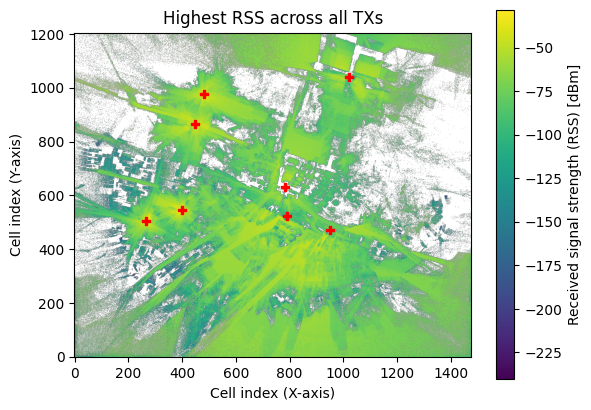

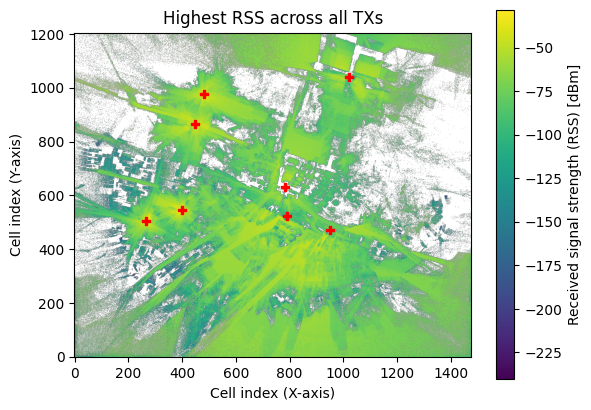

In [7]:
radio_map.show("rss")

In [8]:
rx_id = 0
for rx_info in rx_infos:
    tx_id = rx_info["tx_id"]
    position = rx_info["position"]
    idx_in_tx = rx_info["idx_in_tx"]

    ue = Receiver(
        name=f"UE_TX{tx_id+1}_{idx_in_tx+1}",
        position=position,        # 샘플링된 사용자 위치
        orientation=[0, 0, 0],        # 초기 방향
        display_radius=3,
        color=[0, 0, 1]               # 파란색 표시
    )
    scene.add(ue)

In [9]:
radio_map.tx_association("sinr").shape

(1206, 1476)

In [10]:
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 max_num_paths_per_src = 100_000, # default 1,000,000. how many actual propagation paths per source can be retained
                 samples_per_src = 100_000, # default 1,000,000. how many rays are shot from each source
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=True,
                 refraction=True,
                 synthetic_array=False, # False: 실제 n개 안테나의 경로 각각 계산. 정확하지만 느림.
                 seed=41)

In [11]:
# # # my_cam = Camera(position=[-250,250,150], look_at=[-15,30,28])
# # # if no_preview:
# # #     scene.render(camera=my_cam, paths=paths, radio_map=rm, clip_at=20)
# # # else:
# #     # scene.preview(paths=paths, radio_map=rm, clip_at=20)


# scene.preview(
#     paths=paths,
#     radio_map=radio_map,
    
#     # clip_at=-20,
#     # clip_plane_orientation=(0, 0, 1)
# )

In [ ]:
associated_tx_idxs = [v["tx_id"] for v in rx_infos]
# print("Associated TX indices for each RX: ", assosiated_tx_idxs)

def filter_rxdata_with_associated_tx(array, tx_axis_idx):
    """
        Given array or shape [num_rx, ..., num_tx, ...], filter data for rx_idx only associated tx
    """
    
    array = np.take_along_axis(
        array, 
        indices=np.expand_dims(np.array(associated_tx_idxs), axis=tuple(range(1, len(array.shape)))), 
        axis=tx_axis_idx
    )
    return array

# a_test = filter_rxdata_with_assosiated_tx(a, tx_axis_idx=2) # num_rx, num_rx_ant, num_tx=1, num_tx_ant, num_paths, num_time_steps

In [ ]:
a, tau = paths.cir(normalize_delays=True, 
associated_tx_idxs=associated_tx_idxs,
out_type="numpy")
path_valids = paths.valid.numpy()
valids = filter_rxdata_with_associated_tx(path_valids, tx_axis_idx=2)
# a = filter_rxdata_with_assosiated_tx(a, tx_axis_idx=2) # num_rx, num_rx_ant, num_tx=1, num_tx_ant, num_paths, num_time_steps
# tau = filter_rxdata_with_assosiated_tx(tau, tx_axis_idx=2)
# Shape: 

print("Shape of valids: ", valids.shape)
print("Shape of a     : ", a.shape) # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of tau   : ", tau.shape) # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]

Shape of valids:  (100, 2, 1, 4, 86)
Shape of a     :  (100, 2, 1, 4, 86, 1)
Shape of tau   :  (100, 2, 1, 4, 86)


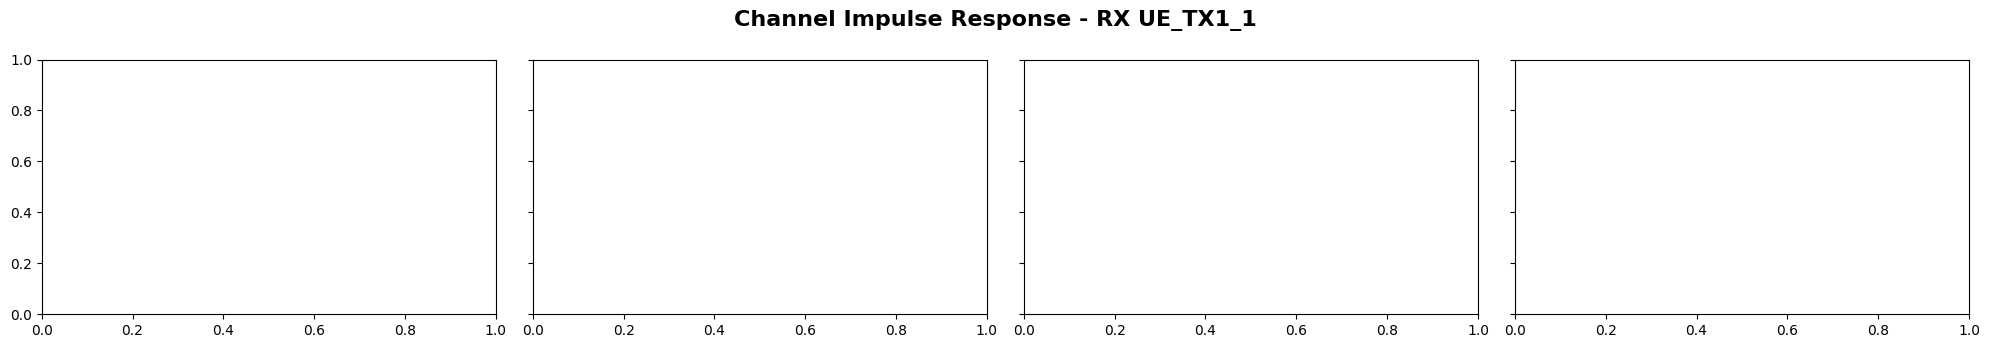

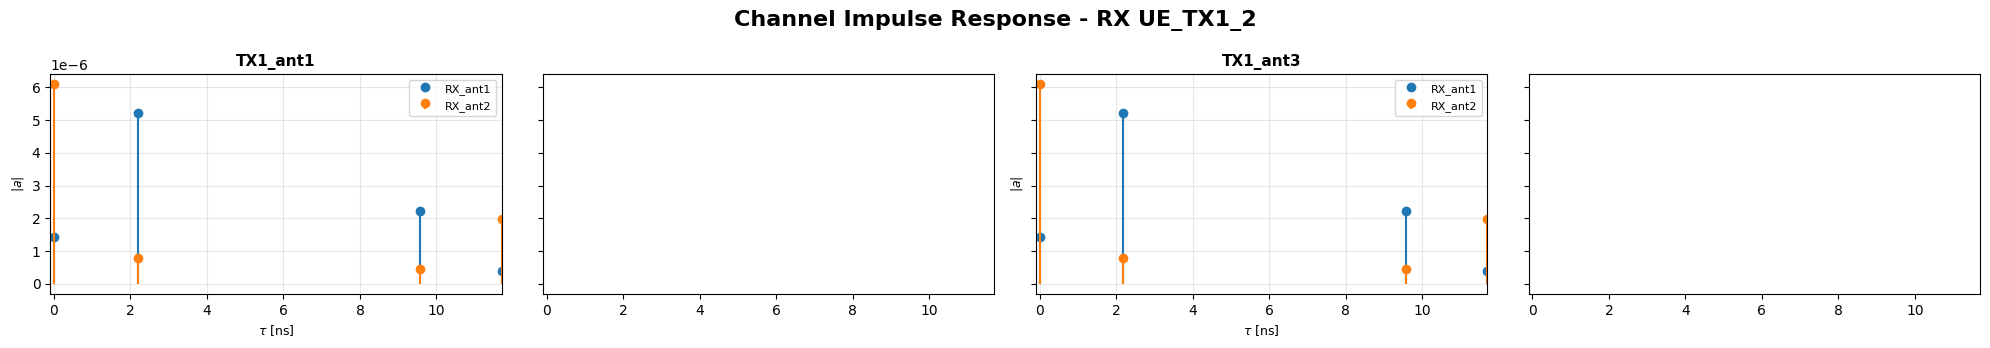

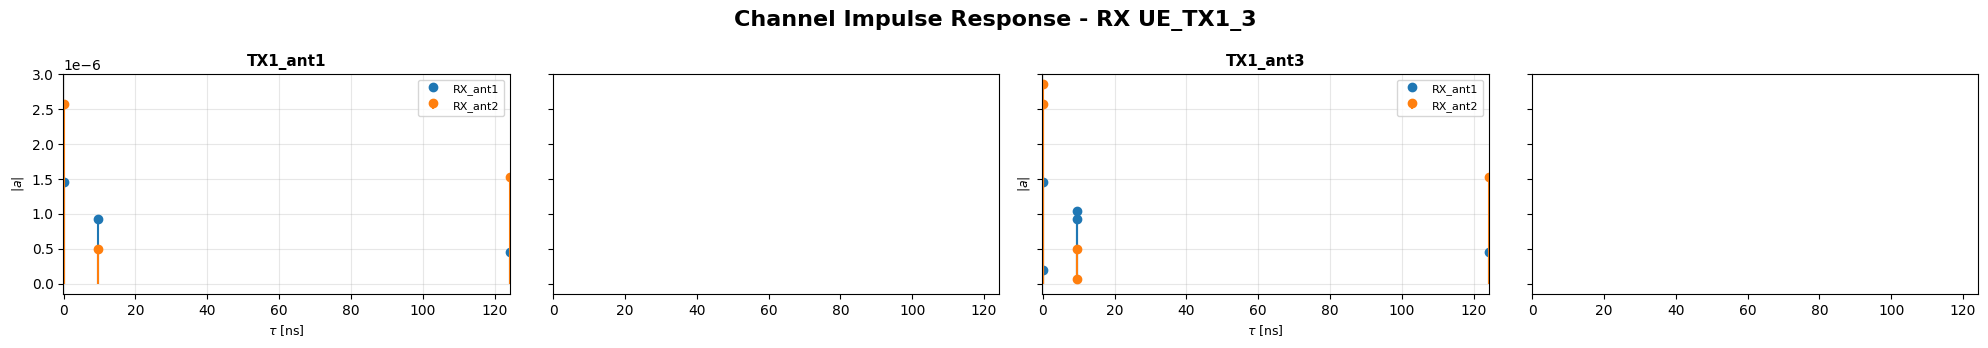

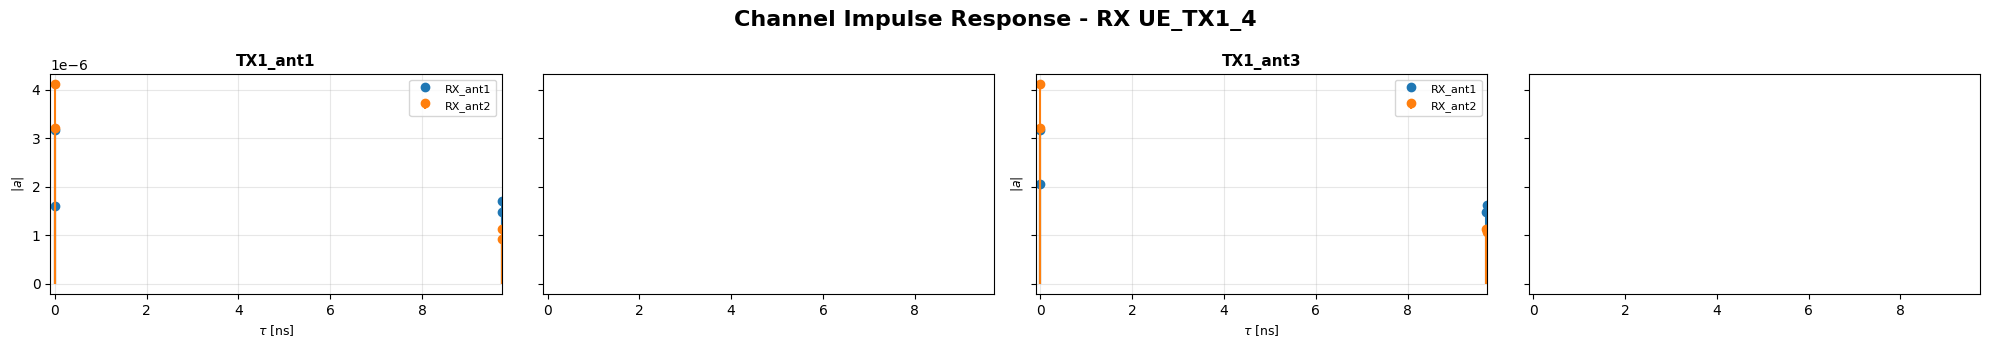

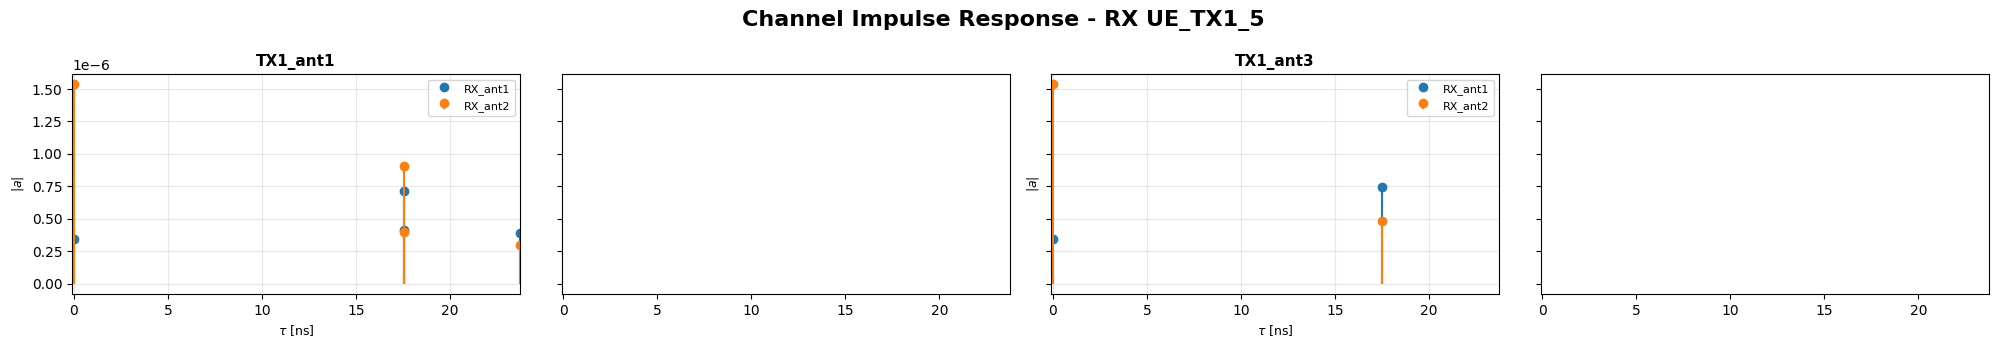

In [14]:
# CIR visualization: 각 RX당 하나의 figure, TX별 행, TX안테나별 열, RX안테나는 같은 subplot에 색상으로 구분
num_rx_to_plot = 5  # 시각화할 RX 수

for rx_id in range(num_rx_to_plot):
    num_rx_ant = a.shape[1]
    num_tx = a.shape[2]
    num_tx_ant = a.shape[3]
    
    # subplot 격자 크기: TX x TX_ant
    nrows = num_tx  # 각 TX를 세로로
    ncols = num_tx_ant  # 각 TX안테나를 가로로
    
    # Figure 생성
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3.5), sharex=True, sharey=True)
    fig.suptitle(f'Channel Impulse Response - RX {list(scene.receivers.keys())[rx_id]}', fontsize=16, fontweight='bold')
    
    # axes를 2D 배열로 변환 (단일 subplot인 경우 대비)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)
    
    rx_valid = valids[rx_id]

    # RX 안테나별 색상 정의
    colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
    # 각 subplot에 모든 RX 안테나의 CIR 그리기
    for tx_id in range(num_tx):
        for tx_ant_id in range(num_tx_ant):
            ax = axes[tx_id, tx_ant_id]
            
            if not np.any(rx_valid[:, tx_id, tx_ant_id]):
                continue

            # 모든 RX 안테나를 같은 subplot에 표시
            for rx_ant_id in range(num_rx_ant):
                color = colors[rx_ant_id % len(colors)]
                
                t = tau[rx_id, rx_ant_id, tx_id, tx_ant_id, :] / 1e-9  # Scale to ns
                a_abs = np.abs(a[rx_id, rx_ant_id, tx_id, tx_ant_id, :, 0])
                # Stem plot with color per RX antenna
                ax.stem(t, a_abs, basefmt=' ', linefmt=f'{color}-', markerfmt=f'{color}o', 
                       label=f'RX_ant{rx_ant_id+1}')
            
            ax.set_xlim(-.1, np.max(tau[rx_id] / 1e-9))
            
            ax.set_title(f'TX{tx_id+1}_ant{tx_ant_id+1}', fontsize=11, fontweight='bold')
            ax.set_xlabel(r'$\tau$ [ns]', fontsize=9)
            ax.set_ylabel(r'$|a|$', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [15]:
dr.flush_malloc_cache()
dr.flush_kernel_cache()


In [17]:
# OFDM system parameters
effective_bandwidth = scene.bandwidth * .9 # 10% 가드 밴드 비율
# Calculate subcarrier spacing
subcarrier_spacing = effective_bandwidth / num_subcarriers

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
print(f"Subcarrier frequencies from {frequencies[0]/1e9:.3f} GHz to {frequencies[-1]/1e9:.3f} GHz")
# Compute channel frequency response
h_freq = paths.cfr(
    frequencies=frequencies,
    associated_tx_idxs=associated_tx_idxs, # if set None, calc from all tx
    normalize=True, # Normalize energy
    normalize_delays=True,
    out_type="numpy"
)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

for rx_id in range(num_rx_to_plot):
    plt.figure()
    plt.plot(np.abs(h_freq)[rx_id,0,0,0,0,:]);
    plt.xlabel("Subcarrier index");
    plt.ylabel(r"|$h_\text{freq}$|");
    plt.title(f"Channel frequency response - RX {list(scene.receivers.keys())[rx_id]}")
    plt.show()

Subcarrier frequencies from -0.180 GHz to 0.180 GHz


NameError: name 'associated_tx_idxs' is not defined